In [38]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import time
import emcee
from multiprocessing import Pool

In [39]:
file = 'data/DES-Dovekie_HD.csv'

with open(file) as f:
    for i, line in enumerate(f):
        if line.startswith('VARNAMES:'):
            header_line = line
            header_idx = i
            break

cols = header_line.replace("VARNAMES:", "").split()

df = pd.read_csv(file, sep='\s+', skiprows=header_idx + 1, header=None).iloc[:, 1:]
df.columns = cols

low_z = df[df['IDSURVEY'] != 10]
high_z = df[df['IDSURVEY'] == 10]
high_z

,CID,IDSURVEY,zHD,zHEL,MU,MUERR,MUERR_VPEC,MUERR_SYS,PROBIA_BEAMS
187,1371046,10,0.07334,0.07411,37.60807,0.1792,0.0307,0.39882,1.00000
188,1318737,10,0.07374,0.07451,37.36177,0.1858,0.0305,0.06818,1.00000
199,1864053,10,0.09333,0.09422,38.14556,0.0994,0.0243,0.06934,1.00000
200,1344303,10,0.09394,0.09475,38.19696,0.2395,0.0242,0.13223,0.99969
201,1317612,10,0.10442,0.10525,38.35683,0.1256,0.0218,0.02734,0.99996
...,...,...,...,...,...,...,...,...,...
1815,1263785,10,1.06420,1.06498,44.23028,0.1451,0.0028,0.03884,0.99765
1816,1842087,10,1.08349,1.08430,44.52159,0.1518,0.0027,0.13563,0.99789
1817,1339609,10,1.12132,1.12212,44.20175,0.1075,0.0026,0.06526,0.98858
1818,1446080,10,1.13057,1.13140,44.52710,0.1585,0.0026,0.11217,0.99945


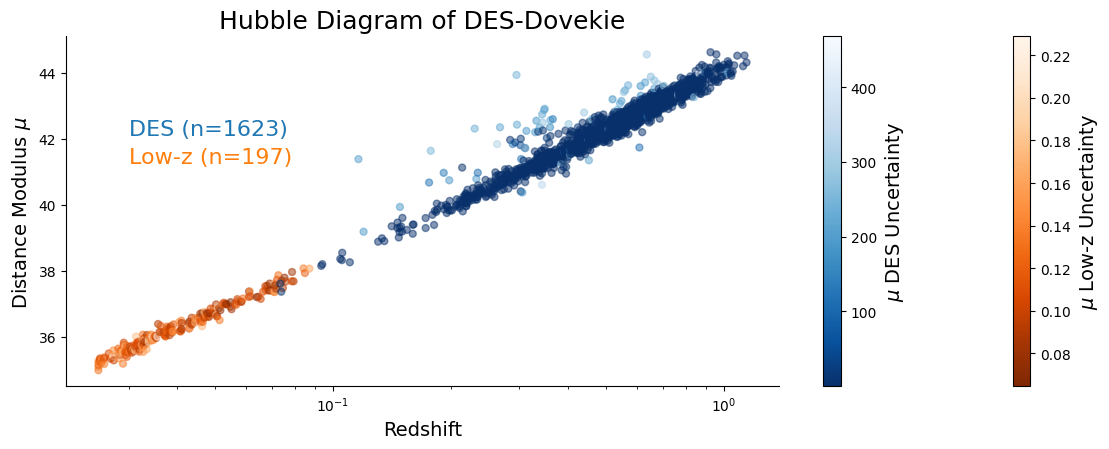

In [40]:
plt.figure(figsize=(12, 4.6))

plt.scatter(low_z['zHD'], low_z['MU'], c=low_z['MUERR'], s=25, cmap='Oranges_r', alpha=0.5)
cbar = plt.colorbar()
cbar.solids.set_alpha(1)
cbar.set_label('$\mu$ Low-z Uncertainty', size=14)
plt.scatter(high_z['zHD'], high_z['MU'], c=high_z['MUERR'], s=25, cmap='Blues_r', alpha=0.5)
cbar = plt.colorbar()
cbar.solids.set_alpha(1)
cbar.set_label('$\mu$ DES Uncertainty', size=14)


plt.xscale('log')
plt.ylabel('Distance Modulus $\mu$', size=14)
plt.xlabel('Redshift', size=14)
plt.title('Hubble Diagram of DES-Dovekie', size=18)
plt.text(0.03, 42, f"DES (n={len(high_z)})", color='tab:blue', size=16, ha='left', va='bottom')
plt.text(0.03, 41.75, f"Low-z (n={len(low_z)})", color='tab:orange', size=16, ha='left', va='top')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

remove high MU uncertainty points

In [41]:
low_z = low_z[low_z['MUERR'] < 0.4]
high_z = high_z[high_z['MUERR'] < 0.4]

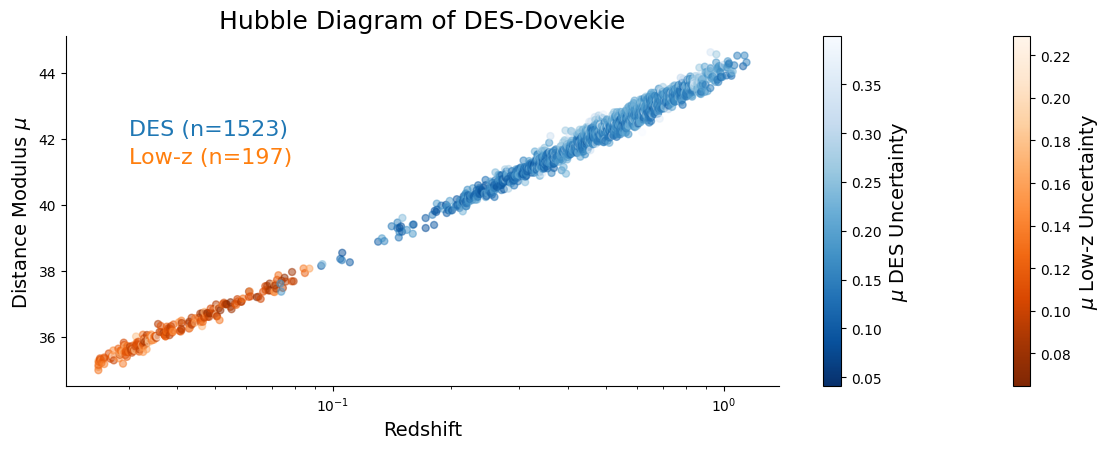

In [42]:
plt.figure(figsize=(12, 4.6))

plt.scatter(low_z['zHD'], low_z['MU'], c=low_z['MUERR'], s=25, cmap='Oranges_r', alpha=0.5)
cbar = plt.colorbar()
cbar.solids.set_alpha(1)
cbar.set_label('$\mu$ Low-z Uncertainty', size=14)
plt.scatter(high_z['zHD'], high_z['MU'], c=high_z['MUERR'], s=25, cmap='Blues_r', alpha=0.5)
cbar = plt.colorbar()
cbar.solids.set_alpha(1)
cbar.set_label('$\mu$ DES Uncertainty', size=14)


plt.xscale('log')
plt.ylabel('Distance Modulus $\mu$', size=14)
plt.xlabel('Redshift', size=14)
plt.title('Hubble Diagram of DES-Dovekie', size=18)
plt.text(0.03, 42, f"DES (n={len(high_z)})", color='tab:blue', size=16, ha='left', va='bottom')
plt.text(0.03, 41.75, f"Low-z (n={len(low_z)})", color='tab:orange', size=16, ha='left', va='top')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# MCMC

In [44]:
def precompute_grid(zs, num_samples=5000):
    """Precompute the integration grid and lookup incidies for fast distance calculations.
    
    Parameters
    ----------
        zs : array_like
            Redshift values where the distances will be evaluated. 
        num_samples : int, optional
            Number of bins used in the Riemann sum integration, default is 5000.
            
    Returns
    -------
        z_mid : np.ndarray
            Midpoints of redshift bins used for integration.
        dz : np.ndarray
            Width of each redshift bin.
        idxs : np.ndarray
            Indicies mapping each input redshift to the integral grid.
            
    Notes
    -----
    - This function should be run ONCE before the MCMC loop
    """
    zs = np.asarray(zs)
    
    edges = np.linspace(0, zs.max(), num_samples) # create evenly spaced bins in redshift space
    dz = np.diff(edges) # bin widths
    z_mid = edges[:-1] + dz / 2 # midpoints (for Riemann integration)
    
    idxs = np.searchsorted(z_mid, zs, side='right') - 1 # index lookup to convert each z to its nearest bin
    idxs = np.clip(idxs, 0, len(z_mid) - 1)

    return z_mid, dz, idxs

def calc_dist(params, z_mid, dz, idxs, zs):
    """Compute the distance in Mpc given parameters and redshift.
    
    Parameters
    ----------
        params : list[float]
            Cosmological parameters [H_0, Om_m, Om_k, Om_l].
        z_mid : np.ndarray
            Midpoints of integration grid.
        dz : np.ndarray
            Bin widths.
        idxs : np.ndarray
            Indices mapping from redshift to integral grid.
        zs : array_like
            Redshift values.
            
    Returns
    -------
    distances : np.ndarray
        Distances (in Mpc) for each redshift.
    
    """
    H_0, Om_m, Om_k, Om_l = params
    zs = np.asarray(zs)

    # hubble parameter as a function of redshifts
    Hz = H_0 * np.sqrt(Om_m * (1.0 + z_mid)**3 +
                      Om_k * (1.0 + z_mid)**2 +
                      Om_l)

    cum_int = np.cumsum(dz / Hz)

    return (1.0 + zs) * 3e5 * cum_int[idxs]

In [ ]:
def ln_prior(params):
    H_0, Om_m, Om_k, Om_l = params
    if H_0 < 0:
        return -np.inf
    elif Om_m < 0 or Om_m > 1:
        return -np.inf
    elif Om_k < -1 or Om_k > 1:
        return -np.inf
    elif Om_l < 0 or Om_l > 1:
        return -np.inf
    elif np.abs(Om_m + Om_k + Om_l - 1) > 1e-5:
        return -np.inf
    else:
        return 0
    
def ln_likelihood(params, grid_params, data_df):
    dist_model = calc_dist(params, *grid_params, data_df['zHD']) * 1e6
    mu_model = 5 * np.log10(dist_model) - 5
    residuals = data_df['MU'] - mu_model
        
    term1 = -0.5 * np.log(2 * np.pi * data_df['MUERR'] ** 2)
    term2 = -0.5 * residuals ** 2 / data_df['MUERR'] ** 2
    return sum(term1 + term2)

def ln_pdf(params, grid_params, data_df):
    p = ln_prior(params)
    if p == -np.inf:
        return -np.inf
    return p + ln_likelihood(params, grid_params, data_df)

In [46]:
n_dim, n_walkers = 4, 10
n_iterations = 5000
p0 = np.random.multivariate_normal(mean=[73, 0.3, 0, 0.7], cov=np.diag([1, 1e-12, 1e-12, 1e-12]), size=n_walkers)

print([ln_prior(x) for x in p0])

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [47]:
with Pool() as pool:
    start = time.time()
    grid_params = precompute_grid(high_z['zHD'])
    sampler = emcee.EnsembleSampler(n_walkers, n_dim, ln_pdf, args=[grid_params, high_z], pool=pool)
    sampler.run_mcmc(p0, n_iterations, progress=True)
    dur = time.time() - start
    print(f'MCMC took {dur:.3f} seconds')

100%|██████████| 5000/5000 [02:18<00:00, 36.17it/s]

MCMC took 138.263 seconds


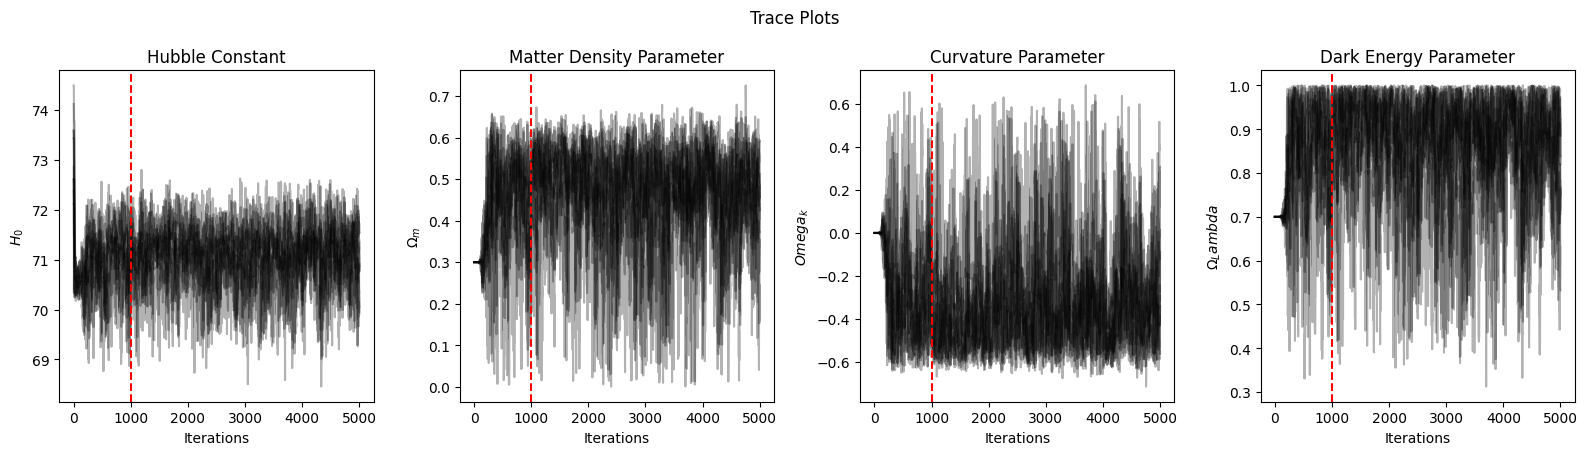

In [52]:
fig, axs = plt.subplots(1, 4, figsize=(16, 4.6))

titles = ['Hubble Constant', 'Matter Density Parameter', 'Curvature Parameter', 'Dark Energy Parameter']
y_labels = [r'$H_0$', r'$\Omega_m$', r'$Omega_k$', r'$\Omega_Lambda$']
for i in range(0, 4):
    axs[i].plot(sampler.get_chain()[:,:,i], 'k', alpha=0.3)
    axs[i].set_xlabel('Iterations')
    axs[i].set_title(titles[i])
    axs[i].set_ylabel(y_labels[i])
    axs[i].axvline(x=1000, color='red', linestyle='dashed')

fig.suptitle('Trace Plots')
plt.tight_layout()
plt.show()

In [57]:
burned = sampler.get_chain(discard=1000, flat=True)

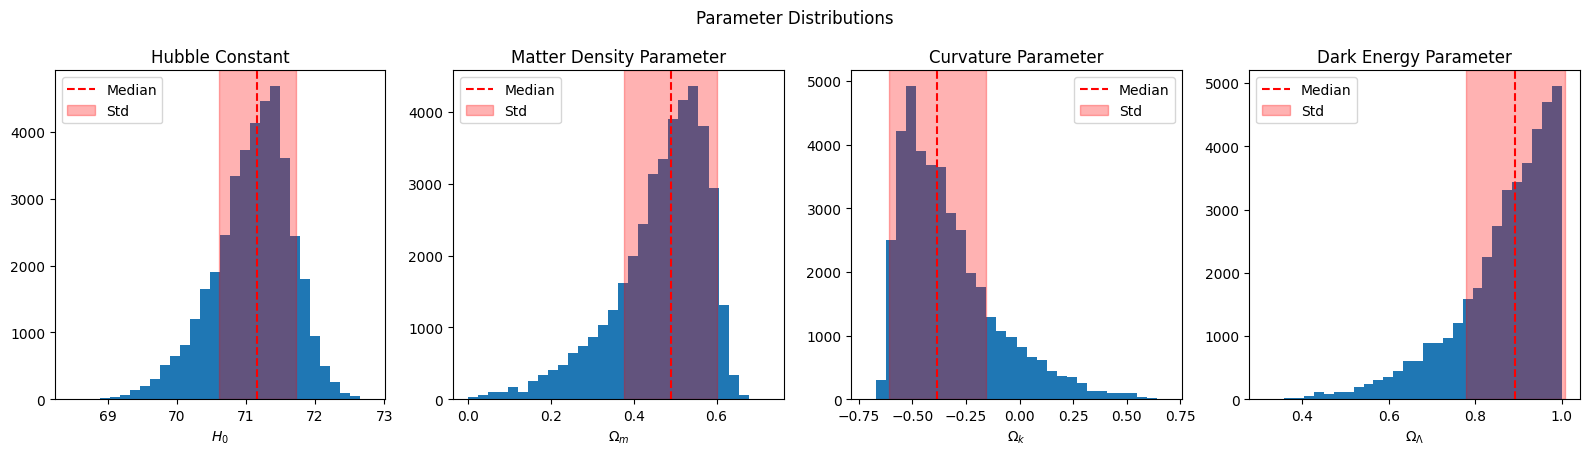

In [58]:
fig, axs = plt.subplots(1, 4, figsize=(16, 4.6))

titles = ['Hubble Constant', 'Matter Density Parameter', 'Curvature Parameter', 'Dark Energy Parameter']
x_labels = [r'$H_0$', r'$\Omega_m$', r'$\Omega_k$', r'$\Omega_\Lambda$']
for i in range(0, 4):
    axs[i].hist(burned[:,i], bins=30)
    axs[i].set_xlabel(x_labels[i])
    axs[i].set_title(titles[i])
    median = np.median(burned[:,i])
    std = np.std(burned[:,i])
    axs[i].axvline(median, color='red', linestyle='dashed', label='Median')
    axs[i].axvspan(median-std, median+std, color='red', alpha=0.3, label='Std')
    axs[i].legend()

fig.suptitle('Parameter Distributions')
plt.tight_layout()
plt.show()

In [51]:
print(f'H_0  = {np.median(burned[:,0]):.2f} ± {np.std(burned[:,0]):.2f} km / s / Mpc')
print(f'Om_m = {np.median(burned[:,1]):.2f} ± {np.std(burned[:,1]):.2f}')
print(f'Om_k = {np.median(burned[:,2]):.2f} ± {np.std(burned[:,2]):.2f}')
print(f'Om_l = {np.median(burned[:,3]):.2f} ± {np.std(burned[:,3]):.2f}')

H_0  = 71.17 ± 0.56 km / s / Mpc
Om_m = 0.49 ± 0.11
Om_k = -0.38 ± 0.22
Om_l = 0.89 ± 0.11
